In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV

In [2]:
import os
import sys
from pathlib import Path
import subprocess

# Ensure project root is importable when running from notebooks/
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(project_root)

# Install required runtime dependencies in the active notebook kernel
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels", "python-dotenv"])

from dotenv import load_dotenv
load_dotenv(project_root / ".env")


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification


False

In [3]:
from src.data.data_loader import DataLoader

dl = DataLoader()

X, y = dl.prepare_X_y()
X.head()

,Volume,LowProportion,HighProportion,Delta Close_(t-1),Delta Close_(t-2),Delta Close_(t-3),Delta Close_(t-4),Delta Close_(t-6),Delta Close_(t-7),Delta Close_(t-8),Delta Close_(t-9),Delta Close_(t-11),Delta Close_(t-14),Delta Close_(t-15),Delta Close_(t-16),Delta Close_(t-21),Delta Close_(t-22),Delta Close_(t-23),Delta Close_(t-29)
Date,,,,,,,,,,,,,,,,,,,
2003-02-24,1.219200e+09,0.983069,1.000054,-24.629883,23.699707,-74.890136,33.700195,80.040039,-55.439941,-83.060059,-4.970215,-94.199707,-44.220215,100.359863,2.720215,-82.790039,-20.619629,-145.529786,-0.830078
2003-02-25,1.495500e+09,0.982515,1.002097,-73.790039,-24.629883,23.699707,-74.890136,152.479980,80.040039,-55.439941,-83.060059,-24.540039,-76.930176,-44.220215,100.359863,-208.700195,-82.790039,-20.619629,23.860351
2003-02-26,1.382300e+09,0.986621,1.000000,-52.240235,-73.790039,-24.629883,23.699707,33.700195,152.479980,80.040039,-55.439941,-4.970215,-67.170410,-76.930176,-44.220215,-39.199707,-208.700195,-82.790039,-37.759766
2003-02-27,1.297100e+09,0.998593,1.012544,-19.840332,-52.240235,-73.790039,-24.629883,-74.890136,33.700195,152.479980,80.040039,-83.060059,-94.199707,-67.170410,-76.930176,78.979981,-39.199707,-208.700195,-68.390136
2003-02-28,1.311700e+09,1.000000,1.010189,62.069824,-19.840332,-52.240235,-73.790039,23.699707,-74.890136,33.700195,152.479980,-55.439941,-24.540039,-94.199707,-67.170410,-56.540039,78.979981,-39.199707,-62.940429


In [4]:
y.head()

Date
2003-02-24    0
2003-02-25    0
2003-02-26    0
2003-02-27    1
2003-02-28    1
dtype: int64

In [5]:
val_size = 0.2
X_train, X_test = DataLoader.time_split_2D(X)
#TODO remove - validation to be done with CV
X_train, X_val = DataLoader.time_split_2D(X_train)
y_train, y_test = DataLoader.time_split_1D(y)
#TODO remove - validation to be done with CV
y_train, y_val = DataLoader.time_split_1D(y_train)

In [6]:
print(y_val.value_counts(normalize=True) * 100)
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

1    53.804348
0    46.195652
Name: proportion, dtype: float64
1    55.098572
0    44.901428
Name: proportion, dtype: float64
1    55.434783
0    44.565217
Name: proportion, dtype: float64


## Random Forest

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None,3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=5) 

In [8]:
rf = RandomForestClassifier(random_state=42)

In [9]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_log_loss',
    refit=True, # Refit an estimator using the best found parameters on the whole dataset
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 3, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [10]:
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation score: -0.573438177328661


In [11]:
best_rf = grid_search.best_estimator_
best_idx = grid_search.best_index_
print(best_idx)

32


In [12]:
print("Best CV ROC-AUC:", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

Best CV ROC-AUC: -0.573438177328661
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}


In [13]:
from sklearn.metrics import roc_auc_score, accuracy_score

best_rf = grid_search.best_estimator_

# Predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Probabilities for ROC-AUC
y_train_prob = best_rf.predict_proba(X_train)[:,1]
y_test_prob = best_rf.predict_proba(X_test)[:,1]

# Metrics
rf_auc_train = roc_auc_score(y_train, y_train_prob)
rf_auc_test = roc_auc_score(y_test, y_test_prob)

rf_acc_train = accuracy_score(y_train, y_train_pred)
rf_acc_test = accuracy_score(y_test, y_test_pred)

print("Model        Train AUC   Test AUC   Train Acc   Test Acc")
print(f"RandomForest   {rf_auc_train:.2f}       {rf_auc_test:.2f}       {rf_acc_train:.2f}       {rf_acc_test:.2f}")

Model        Train AUC   Test AUC   Train Acc   Test Acc
RandomForest   0.84       0.75       0.75       0.68


In [14]:
import os
from joblib import dump

# Create 'models' folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Path to save the model
model_path = 'models/best_rf_model.joblib'

# Save the model
dump(best_rf, model_path)
print(f"Model saved at {model_path}")

Model saved at models/best_rf_model.joblib


In [15]:
#rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
#rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_val)
y_prob = best_rf.predict_proba(X_val)[:,1]

In [16]:
print("Random Forest Accuracy:", best_rf.score(X_val, y_val))
print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

Random Forest Accuracy: 0.6847826086956522
              precision    recall  f1-score   support

           0       0.70      0.56      0.62       340
           1       0.68      0.80      0.73       396

    accuracy                           0.68       736
   macro avg       0.69      0.68      0.68       736
weighted avg       0.69      0.68      0.68       736

ROC-AUC: 0.7548351158645277


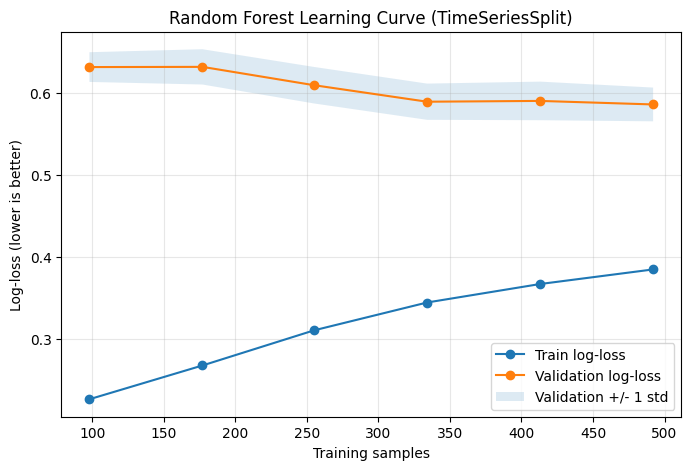

In [17]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Learning curve with time-series splits to inspect bias/variance vs training size
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rf,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=tscv,
    scoring="neg_log_loss",
    n_jobs=-1,
    shuffle=False,
    error_score="raise",
)

train_log_loss = -train_scores
val_log_loss = -val_scores

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_log_loss.mean(axis=1), marker="o", label="Train log-loss")
plt.plot(train_sizes, val_log_loss.mean(axis=1), marker="o", label="Validation log-loss")
plt.fill_between(
    train_sizes,
    val_log_loss.mean(axis=1) - val_log_loss.std(axis=1),
    val_log_loss.mean(axis=1) + val_log_loss.std(axis=1),
    alpha=0.15,
    label="Validation +/- 1 std",
)
plt.xlabel("Training samples")
plt.ylabel("Log-loss (lower is better)")
plt.title("Random Forest Learning Curve (TimeSeriesSplit)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [18]:
from sklearn.model_selection import cross_validate

# Time-series CV validation on the training window using the tuned model
cv_scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
}

cv_results = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=tscv,
    scoring=cv_scoring,
    return_train_score=True,
    n_jobs=-1,
    error_score="raise",
)

for metric in ["accuracy", "f1", "roc_auc", "neg_log_loss"]:
    test_key = f"test_{metric}"
    train_key = f"train_{metric}"
    test_mean = cv_results[test_key].mean()
    test_std = cv_results[test_key].std()
    train_mean = cv_results[train_key].mean()
    if metric == "neg_log_loss":
        # Convert from negative log-loss back to regular log-loss for readability
        print(
            f"{metric}: train={-train_mean:.4f} | val={-test_mean:.4f} (+/- {test_std:.4f})"
        )
    else:
        print(
            f"{metric}: train={train_mean:.4f} | val={test_mean:.4f} (+/- {test_std:.4f})"
        )

accuracy: train=0.8041 | val=0.7078 (+/- 0.0303)
f1: train=0.8261 | val=0.7336 (+/- 0.0271)
roc_auc: train=0.8917 | val=0.7717 (+/- 0.0423)
neg_log_loss: train=0.4597 | val=0.5734 (+/- 0.0256)


## Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],  # type of regularization
    'solver': ['saga'],                     # saga supports all penalties including l1 and elasticnet
    'max_iter': [500, 1000]                 # ensure convergence
}

In [20]:
logreg = LogisticRegression()
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='neg_log_loss',   
    cv=5,
    n_jobs=-1,
    verbose=1
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'C': 0.01, 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}
Best CV ROC-AUC: 0.7858729656669908
Test ROC-AUC: 0.7426398852223817


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to 

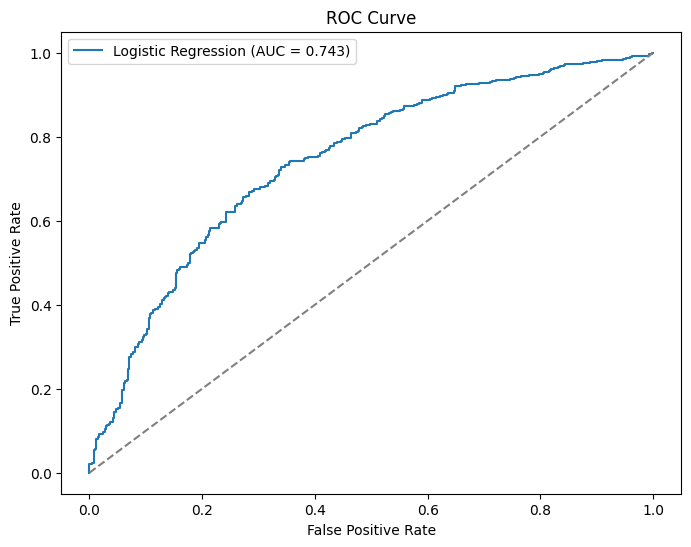

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression param grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['saga'],
    'max_iter': [500]
}

# Grid search
logreg = LogisticRegression()
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

# Best model
best_logreg = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

# Predictions
y_pred_prob = best_logreg.predict_proba(X_test_scaled)[:,1]

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("Test ROC-AUC:", roc_auc)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import accuracy_score, roc_auc_score

# --- Predictions on train set ---
y_train_pred_prob = best_logreg.predict_proba(X_train_scaled)[:, 1]
y_train_pred_class = best_logreg.predict(X_train_scaled)

# Train metrics
logreg_train_accuracy = accuracy_score(y_train, y_train_pred_class)
logreg_train_roc_auc = roc_auc_score(y_train, y_train_pred_prob)

# --- Predictions on test set ---
y_test_pred_prob = best_logreg.predict_proba(X_test_scaled)[:, 1]
y_test_pred_class = best_logreg.predict(X_test_scaled)

# Test metrics
logreg_test_accuracy = accuracy_score(y_test, y_test_pred_class)
logreg_test_roc_auc = roc_auc_score(y_test, y_test_pred_prob)

print(f"Train Accuracy: {logreg_train_accuracy:.3f}, Train ROC-AUC: {logreg_train_roc_auc:.3f}")
print(f"Test Accuracy:  {logreg_test_accuracy:.3f}, Test ROC-AUC:  {logreg_test_roc_auc:.3f}")

Train Accuracy: 0.711, Train ROC-AUC: 0.784
Test Accuracy:  0.683, Test ROC-AUC:  0.743


## XGBoost

In [23]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

val_size = 0.2
X_train, X_test = DataLoader.time_split_2D(X)
#TODO remove - validation to be done with CV
X_train, X_val = DataLoader.time_split_2D(X_train)
y_train, y_test = DataLoader.time_split_1D(y)
#TODO remove - validation to be done with CV
y_train, y_val = DataLoader.time_split_1D(y_train)

In [24]:
from sklearn.model_selection import TimeSeriesSplit

n_splits = 5  # example
tscv = TimeSeriesSplit(n_splits=n_splits)

In [25]:
param_grid_small = {
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'n_estimators': [100,200],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.01],
    'reg_lambda': [1, 1.5]
}

In [26]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_small,
    scoring='neg_log_loss',         # choose metric appropriate for your problem
    cv=tscv,                   # TimeSeriesSplit
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:42:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:42:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:42:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/

{'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 1.5, 'subsample': 0.7}


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:42:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 1.5, 'subsample': 0.7}


In [28]:
print("Best CV ROC-AUC:", grid_search.best_score_)

Best CV ROC-AUC: -0.5682308166528011


In [29]:
best_xgb = grid_search.best_estimator_
print(best_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [30]:
import joblib
model_dir = '../models/'
best_model_path = os.path.join(model_dir, "xgb_best_model.pkl")
joblib.dump(grid_search.best_estimator_, best_model_path)

print(f"Best XGBoost model saved at {best_model_path}")

Best XGBoost model saved at ../models/xgb_best_model.pkl


In [31]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Training predictions
y_train_pred = best_xgb.predict(X_train)
y_train_prob = best_xgb.predict_proba(X_train)[:,1]

# Test predictions
y_test_pred = best_xgb.predict(X_test)
y_test_prob = best_xgb.predict_proba(X_test)[:,1]

# Metrics
xgb_train_acc = accuracy_score(y_train, y_train_pred)
xgb_train_auc = roc_auc_score(y_train, y_train_prob)
xgb_test_acc = accuracy_score(y_test, y_test_pred)
xgb_test_auc = roc_auc_score(y_test, y_test_prob)

print(f"Train Accuracy: {xgb_train_acc:.3f}, Train ROC-AUC: {xgb_train_auc:.3f}")
print(f"Test Accuracy: {xgb_test_acc:.3f}, Test ROC-AUC: {xgb_test_auc:.3f}")

Train Accuracy: 0.757, Train ROC-AUC: 0.837
Test Accuracy: 0.682, Test ROC-AUC: 0.744


In [32]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
results[['mean_train_score', 'mean_test_score', 'params']].sort_values(by='mean_test_score', ascending=False)

,mean_train_score,mean_test_score,params
75,-0.438139,-0.568231,"{'colsample_bytree': 0.7, 'gamma': 0.1, 'learn..."
11,-0.438040,-0.568530,"{'colsample_bytree': 0.7, 'gamma': 0, 'learnin..."
73,-0.438281,-0.568700,"{'colsample_bytree': 0.7, 'gamma': 0.1, 'learn..."
9,-0.438187,-0.568825,"{'colsample_bytree': 0.7, 'gamma': 0, 'learnin..."
8,-0.435571,-0.569207,"{'colsample_bytree': 0.7, 'gamma': 0, 'learnin..."
...,...,...,...
54,-0.089206,-0.668595,"{'colsample_bytree': 0.7, 'gamma': 0, 'learnin..."
55,-0.097066,-0.669560,"{'colsample_bytree': 0.7, 'gamma': 0, 'learnin..."
118,-0.090417,-0.671731,"{'colsample_bytree': 0.7, 'gamma': 0.1, 'learn..."
52,-0.089489,-0.675732,"{'colsample_bytree': 0.7, 'gamma': 0, 'learnin..."


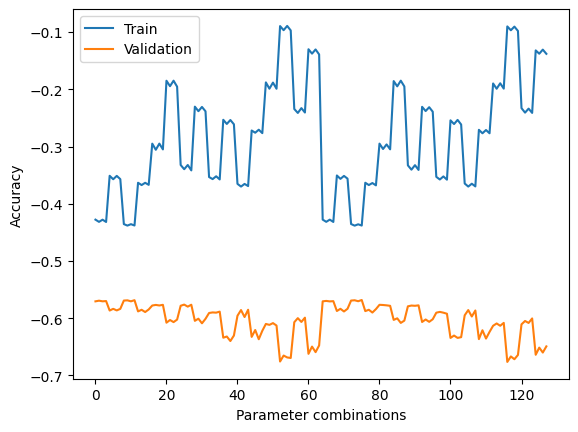

In [33]:
import matplotlib.pyplot as plt

train_scores = results['mean_train_score']
test_scores = results['mean_test_score']

plt.plot(train_scores, label='Train')
plt.plot(test_scores, label='Validation')
plt.xlabel('Parameter combinations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## LSTM - without lag

In [34]:
import pandas as pd
import numpy as np
import datetime
index_processed_path = '../data/StockExchangeData/indexProcessed.csv'

index_processed = pd.read_csv(index_processed_path, parse_dates=[1])

index_mask = index_processed['Index'] == 'NYA'
date_mask = index_processed['Date'] >= datetime.datetime(2003,1,8)

nya_df = (
    index_processed[index_mask & date_mask]
    .set_index('Date')
    .drop(columns=['Index', 'CloseUSD'])
)

# Target (next day direction)
nya_df['Target'] = (nya_df['Close'].shift(-1) > nya_df['Close']).astype(int)

# Lag for ratios
nya_df['Last Close'] = nya_df['Close'].shift(1)

# Engineered features
# Ratios relative to previous close
nya_df['Open_Close'] = (nya_df['Open'] - nya_df['Last Close']) / nya_df['Last Close']
nya_df['High_Close'] = (nya_df['High'] - nya_df['Last Close']) / nya_df['Last Close']
nya_df['Low_Close'] = (nya_df['Low'] - nya_df['Last Close']) / nya_df['Last Close']
nya_df['VolumeReturn'] = nya_df['Volume'] * ((nya_df['Close'] - nya_df['Open']) / nya_df['Open'])
nya_df['Volatility5'] = nya_df['Close'].rolling(5).std()
# Lagged returns
nya_df['Return1'] = nya_df['Close'].pct_change(1)
nya_df['Return5'] = nya_df['Close'].pct_change(5)
nya_df['Return10'] = nya_df['Close'].pct_change(10)

# Moving averages
nya_df['SMA5'] = nya_df['Close'].rolling(5).mean()
nya_df['SMA10'] = nya_df['Close'].rolling(10).mean()

# sort
nya_df = nya_df.sort_index()
nya_df = nya_df.dropna()


In [35]:
features = [
    'Open',
    'Close',
    'Volume',
    'Open_Close',
    'Low_Close',
    'High_Close',
    'VolumeReturn',
    'Volatility5',
    'Return1',
    'Return5',
    'Return10',
    'SMA5',
    'SMA10'
]

X = nya_df[features]
y = nya_df['Target']

In [36]:
SEQ_LEN = 30  # number of timesteps

def create_sequences(X, y, seq_length=SEQ_LEN):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y.iloc[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create sequences
X_seq, y_seq = create_sequences(pd.DataFrame(X_scaled, columns=X.columns), y)

# Train/test split
train_index_seq = int((1 - test_size) * X_seq.shape[0])
X_train_final = X_seq[:train_index_seq]
y_train_final = y_seq[:train_index_seq].astype(int)
X_test_final = X_seq[train_index_seq:]
y_test_final = y_seq[train_index_seq:].astype(int)

print("X_train_final shape:", X_train_final.shape)  # should be (samples, SEQ_LEN, features)
print("X_test_final shape:", X_test_final.shape)

NameError: name 'test_size' is not defined

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

NUM_FEATURES = X_train_final.shape[2]

model_lstm = Sequential([
    LSTM(50, activation='tanh', kernel_regularizer=l2(0.001), input_shape=(SEQ_LEN, NUM_FEATURES)),
    Dense(25, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

In [ ]:
es = EarlyStopping(
    monitor='val_AUC',
    mode='max',
    patience=5,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_final, y_train_final,
    validation_data=(X_test_final, y_test_final),
    epochs=30,
    batch_size=32,
    callbacks=[es],
    verbose=2
)

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.show()

In [ ]:
# LSTM metrics from training history
lstm_acc_train = history.history["accuracy"][-1]        # last epoch train accuracy
lstm_acc_val = history.history["val_accuracy"][-1]      # last epoch val accuracy

lstm_auc_train = history.history["AUC"][-1]             # last epoch train AUC
lstm_auc_val = history.history["val_AUC"][-1]           # last epoch val AUC

print(f"LSTM Train Accuracy: {lstm_acc_train:.4f}")
print(f"LSTM Validation Accuracy: {lstm_acc_val:.4f}")
print(f"LSTM Train ROC-AUC: {lstm_auc_train:.4f}")
print(f"LSTM Validation ROC-AUC: {lstm_auc_val:.4f}")

## LSTM

In [37]:
X, y = dl.prepare_X_y() 
X.head()

,Volume,LowProportion,HighProportion,Delta Close_(t-1),Delta Close_(t-2),Delta Close_(t-3),Delta Close_(t-4),Delta Close_(t-6),Delta Close_(t-7),Delta Close_(t-8),Delta Close_(t-9),Delta Close_(t-11),Delta Close_(t-14),Delta Close_(t-15),Delta Close_(t-16),Delta Close_(t-21),Delta Close_(t-22),Delta Close_(t-23),Delta Close_(t-29)
Date,,,,,,,,,,,,,,,,,,,
2003-02-24,1.219200e+09,0.983069,1.000054,-24.629883,23.699707,-74.890136,33.700195,80.040039,-55.439941,-83.060059,-4.970215,-94.199707,-44.220215,100.359863,2.720215,-82.790039,-20.619629,-145.529786,-0.830078
2003-02-25,1.495500e+09,0.982515,1.002097,-73.790039,-24.629883,23.699707,-74.890136,152.479980,80.040039,-55.439941,-83.060059,-24.540039,-76.930176,-44.220215,100.359863,-208.700195,-82.790039,-20.619629,23.860351
2003-02-26,1.382300e+09,0.986621,1.000000,-52.240235,-73.790039,-24.629883,23.699707,33.700195,152.479980,80.040039,-55.439941,-4.970215,-67.170410,-76.930176,-44.220215,-39.199707,-208.700195,-82.790039,-37.759766
2003-02-27,1.297100e+09,0.998593,1.012544,-19.840332,-52.240235,-73.790039,-24.629883,-74.890136,33.700195,152.479980,80.040039,-83.060059,-94.199707,-67.170410,-76.930176,78.979981,-39.199707,-208.700195,-68.390136
2003-02-28,1.311700e+09,1.000000,1.010189,62.069824,-19.840332,-52.240235,-73.790039,23.699707,-74.890136,33.700195,152.479980,-55.439941,-24.540039,-94.199707,-67.170410,-56.540039,78.979981,-39.199707,-62.940429


In [38]:
y.head()

Date
2003-02-24    0
2003-02-25    0
2003-02-26    0
2003-02-27    1
2003-02-28    1
dtype: int64

In [39]:
lag_cols = [c for c in X.columns if "Delta Close" in c]
static_cols = ["Volume", "LowProportion", "HighProportion"]

In [40]:
X_static = X[static_cols]
X_lags = X[lag_cols]

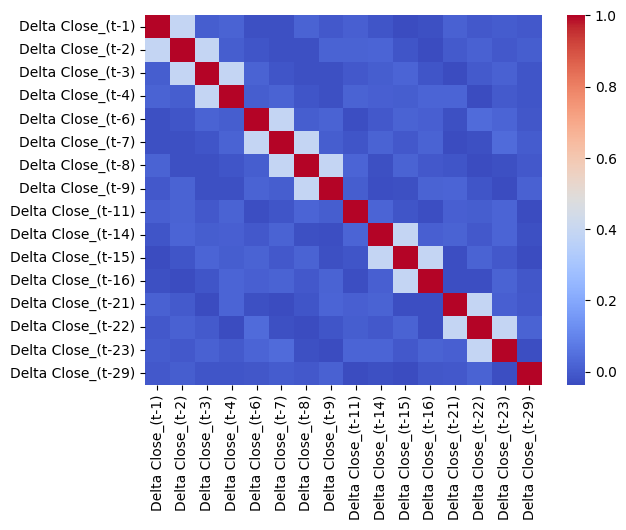

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(X_lags.corr(), cmap="coolwarm", annot=False)
plt.show()

In [42]:
import numpy as np

# Convert lagged features to 3D: (samples, timesteps, features)
# Here, each sample is just 1 row with all lagged columns as timesteps
X_lags_3d = np.expand_dims(X_lags.values, axis=0)  # shape: (1, timesteps, features)

In [43]:
def create_lstm_input(X_lags, X_static, y, window_size=10):
    """
    Converts lagged and static features into LSTM-ready 3D arrays.
    """
    X_lstm = []
    y_lstm = []
    
    for i in range(len(X_lags) - window_size):
        # Sequence of lagged features
        seq = X_lags.iloc[i:i+window_size].values
        # Repeat static features for each timestep
        static_seq = np.repeat(X_static.iloc[i+window_size-1].values.reshape(1, -1), window_size, axis=0)
        # Combine lagged + static features
        combined = np.hstack([seq, static_seq])
        
        X_lstm.append(combined)
        y_lstm.append(y.iloc[i+window_size])
    
    return np.array(X_lstm), np.array(y_lstm)

# Example:
window_size = 10
X_lstm, y_lstm = create_lstm_input(X_lags, X_static, y, window_size)
print("X shape:", X_lstm.shape)  # (samples, timesteps, features)
print("y shape:", y_lstm.shape)

X shape: (4588, 10, 19)
y shape: (4588,)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(64, input_shape=(X_lstm.shape[1], X_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))  # Use sigmoid for binary output

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy','auc'])
model.summary()

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:

import numpy as np
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# Parameters
window_size = 10  # adjust as needed
num_features = X_train.shape[1]  # original feature count

X_lstm, y_lstm = [], []
for i in range(window_size, len(X_train)):
    X_lstm.append(X_train.iloc[i-window_size:i].values)
    y_lstm.append(y_train.iloc[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print(X_lstm.shape, y_lstm.shape)

X_lstm = np.array(X_lstm)  # shape: (num_samples, window_size, num_features)
y_lstm = np.array(y_lstm)

print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

def create_model(units=64, dropout=0.2, input_shape=(window_size, num_features)):
    model = Sequential()
    model.add(LSTM(units, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

keras_clf = KerasClassifier(
    model=create_model,
    epochs=20,
    batch_size=32,
    verbose=1
)

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'model__units': [32, 64],
    'model__dropout': [0.2, 0.3],
    'model__input_shape': [(window_size, num_features)]  # critical for LSTM
}

grid = GridSearchCV(
    estimator=keras_clf,
    param_grid=param_grid,
    scoring='neg_log_loss',   # maximize neg_log_loss = minimize log loss
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

history = grid.fit(X_lstm, y_lstm)


print("Best hyperparameters:", grid.best_params_)

(2932, 10, 19) (2932,)
X_lstm shape: (2932, 10, 19)
y_lstm shape: (2932,)
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20
Epoch 1/20


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7970 
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6946
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7515
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7427
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6950
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6954 
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7420
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7228
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7698
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.6707
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7166
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7215
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7073
Epoch 2/20
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6911 
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6923
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6894
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6949
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6800
Epoch 18/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6973
Epoch 16/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6994
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.69268
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6917
Epoch 19/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6961
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.69935
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6970
Epoch 17/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6940
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6883
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6910
Epoch 20/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6960 
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6876 
Epoch 18/20
16/16 ━━━

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7024
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6924 
Epoch 19/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6936
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6909
Epoch 16/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6992
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6954
Epoch 20/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6972
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6926
Epoch 17/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6874
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6927
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6997
Epoch 14/20
[CV] END model__dropout=0.2, model__input_shape=(10, 19), model__units=32; total time=   4.0s
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6956
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6881
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6967
Epoch 

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6876
Epoch 15/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6893
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6956
Epoch 19/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6875
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6982
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6935
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7016
Epoch 16/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6886
Epoch 20/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6907
Epoch 15/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6895 
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6873
Epoch 14/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6954
Epoch 17/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6909
[CV] END model__dropout=0.2, model__input_shape=(10, 19), model__units=64; total time=   4.5s
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6993
Epoch

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6932
Epoch 16/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7127
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6939
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.69376
Epoch 13/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6935
Epoch 18/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6866
Epoch 15/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7145 
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6893
Epoch 17/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6988
Epoch 13/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6898
Epoch 19/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6943 
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6860
Epoch 16/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6898
Epoch 14/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6928
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6900
Epoch 18/20
31/31 ━━━━

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7075 
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6973
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7107 
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6859
Epoch 19/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7107
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6932
 1/46 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6806[CV] END model__dropout=0.2, model__input_shape=(10, 19), model__units=64; total time=   5.6s
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6901 
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6951
Epoch 16/20
Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6980
Epoch 6/20
 1/77 ━━━━━━━━━━━━━━━━━━━━ 25s 330ms/step - loss: 0.7022

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6935 
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6889
Epoch 17/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7057  
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6877
Epoch 20/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6962 
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6978
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6926 
Epoch 16/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7151 
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6912
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7053
Epoch 17/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6916
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6863
[CV] END model__dropout=0.2, model__input_shape=(10, 19), model__units=32; total time=   5.9s
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6927
Epoch 17/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7008
Epoc

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6939 
Epoch 19/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7036  
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6903
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6849 
Epoch 20/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6921
Epoch 18/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7118
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7119 
56/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6843[CV] END model__dropout=0.3, model__input_shape=(10, 19), model__units=32; total time=   2.9s
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6972
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6985
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6889
Epoch 19/20
37/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7041

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

 1/31 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.6742Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7069 
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6940 
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7001
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6973
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6879
Epoch 20/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6936
Epoch 19/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6862
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6955
Epoch 16/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7023 
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6882 
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6901
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6864
[CV] END model__dropout=0.2, model__input_shape=(10, 19), model__units=64; total time=   6.8s
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6876
Epoch 15

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6929
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6891
Epoch 17/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6915
Epoch 16/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7565
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6950 
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6972
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.70817
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6890
Epoch 17/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6895
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6924
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6981
Epoch 12/20
 1/16 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.6171[CV] END model__dropout=0.2, model__input_shape=(10, 19), model__units=32; total time=   7.1s
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6875
Epoch 18/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7152
Epoch 3/20
13/62 ━━━━

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7084 
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6935
Epoch 19/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6955
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6942 
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6993
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6891 
Epoch 20/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6992
Epoch 14/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7038
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6988
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6897 
[CV] END model__dropout=0.3, model__input_shape=(10, 19), model__units=32; total time=   3.9s
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7433
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6902
Epoch 19/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7041
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6920
Epoch 9/2

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7149
23/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6838 Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7086
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6921
Epoch 16/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.69389
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7010
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7046
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6913 
Epoch 20/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7182 
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6913
Epoch 17/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.71910
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7016
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7024 
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6982
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6975
Epoch 18/20
31/31 ━━━━━━━━━━━━━━━━

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6926
Epoch 20/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6888
Epoch 17/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7069
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.71075
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6933
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7032 
Epoch 18/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6955
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7033
Epoch 9/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6911
[CV] END model__dropout=0.3, model__input_shape=(10, 19), model__units=32; total time=   4.5s
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7002 
Epoch 19/20
33/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7003  

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7039
Epoch 20/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6912
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7070
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6950
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7047
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7143 
[CV] END model__dropout=0.3, model__input_shape=(10, 19), model__units=64; total time=   3.1s
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6966
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6957 
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7060
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6873 
Epoch 14/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6967
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7077
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7008
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6932 
Epoch 9/

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6962
Epoch 15/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6892
Epoch 16/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6947
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6921
Epoch 11/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6893
Epoch 16/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6934
21/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6938 Epoch 17/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6922
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6940
Epoch 9/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6916
Epoch 17/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6883
Epoch 18/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6889
Epoch 18/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6958
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6911
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6897
Epoch 19/20
46/46 ━━━━━━━━━━━━━━━━━━

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6879
Epoch 17/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6887
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6908
Epoch 18/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6915
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6903
Epoch 19/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6905
Epoch 15/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6885
Epoch 20/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6908
Epoch 16/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6911
[CV] END model__dropout=0.3, model__input_shape=(10, 19), model__units=64; total time=   5.2s
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6914
Epoch 17/20
 1/77 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6872

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6894
Epoch 18/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6896
Epoch 19/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6898
Epoch 20/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6900
[CV] END model__dropout=0.3, model__input_shape=(10, 19), model__units=64; total time=   5.8s
Epoch 1/20


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/chhaganimahima/Desktop/global-stock-index-ml-classificati

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7070
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7026
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7028
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7018
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6939
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6973
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6970
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6960
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6912
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6896
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6939
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6917
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6933
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6889
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6919
Epoch 16/20
92/92 ━━━━━━━━━━━━

In [59]:
best_lstm = grid.best_estimator_.model_ 

In [62]:
from sklearn.model_selection import train_test_split

# Split raw training data into train/validation
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train, y_train, test_size=0.2, shuffle=False
)

# Parameters
window_size = 10
num_features = X_train_raw.shape[1]

# Function to create sequences
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X.iloc[i-window_size:i].values)
        y_seq.append(y.iloc[i])
    return np.array(X_seq), np.array(y_seq)

# Create sequences
X_lstm, y_lstm = create_sequences(X_train_raw, y_train_raw, window_size)
X_val_lstm, y_val_lstm = create_sequences(X_val_raw, y_val_raw, window_size)

print(X_lstm.shape, y_lstm.shape)
print(X_val_lstm.shape, y_val_lstm.shape)

(2343, 10, 19) (2343,)
(579, 10, 19) (579,)


In [63]:
split_idx = int(0.8 * len(X_lstm))
X_train_seq = X_lstm[:split_idx]
y_train_seq = y_lstm[:split_idx]

X_val_lstm = X_lstm[split_idx:]
y_val_lstm = y_lstm[split_idx:]

In [64]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Training predictions
y_train_prob = best_lstm.predict(X_lstm)[:,0]
y_train_pred = (y_train_prob >= 0.5).astype(int)

# Validation predictions
y_val_prob = best_lstm.predict(X_val_lstm)[:,0]
y_val_pred = (y_val_prob >= 0.5).astype(int)

# Metrics
lstm_train_acc = accuracy_score(y_lstm, y_train_pred)
lstm_train_auc = roc_auc_score(y_lstm, y_train_prob)

lstm_val_acc = accuracy_score(y_val_lstm, y_val_pred)
lstm_val_auc = roc_auc_score(y_val_lstm, y_val_prob)

print(f"LSTM Train Accuracy: {lstm_train_acc:.3f}, Train ROC-AUC: {lstm_train_auc:.3f}")
print(f"LSTM Validation Accuracy: {lstm_val_acc:.3f}, Validation ROC-AUC: {lstm_val_auc:.3f}")

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
LSTM Train Accuracy: 0.546, Train ROC-AUC: 0.511
LSTM Validation Accuracy: 0.535, Validation ROC-AUC: 0.519


## Comaprison between all models

In [ ]:
import pandas as pd

# Create a dictionary of your metrics
model_metrics = {
    "Model": ["Random Forest", "Logistic Regression", "XGBClassifier","LSTM"],
    "Train Accuracy": [rf_acc_train, logreg_train_accuracy,xgb_train_acc, lstm_train_acc],
    "Validation/Test Accuracy": [rf_acc_test, logreg_test_accuracy,xgb_test_acc, lstm_val_acc],
    "Train ROC-AUC": [rf_auc_train, logreg_train_roc_auc,xgb_train_auc, lstm_train_auc],
    "Validation/Test ROC-AUC": [rf_auc_test, logreg_test_roc_auc,xgb_test_auc, lstm_val_auc],
    "Notes": [
        "High accuracy and ROC-AUC on train; slight overfitting; best overall performance",
        "Moderate train/test metrics; consistent performance; less overfitting than RF",
        "Low metrics; overfitting to large extent",
        "Low metrics; underfitting; not capturing sequence patterns effectively"
    ]
}

df_comparison = pd.DataFrame(model_metrics)

def highlight_best(subset):
    # Highlight the max value in each column with a subtle pastel
    is_max = subset == subset.max()
    return ['background-color: #d4edda; color: black' if v else '' for v in is_max]


def highlight_worst(subset):
    # Highlight the min value with a soft pastel
    is_min = subset == subset.min()
    return ['background-color: #f8d7da; color: black' if v else '' for v in is_min]


# Apply styling
styled_table = (
    df_comparison.style
    .format("{:.3f}", subset=["Train Accuracy", "Validation/Test Accuracy", "Train ROC-AUC", "Validation/Test ROC-AUC"])
    .apply(highlight_best, subset=["Validation/Test Accuracy", "Validation/Test ROC-AUC"])
    .apply(highlight_worst, subset=["Validation/Test Accuracy", "Validation/Test ROC-AUC"])
    .set_properties(**{'text-align': 'center', 'font-size': '13pt'})
)

styled_table

,Model,Train Accuracy,Validation/Test Accuracy,Train ROC-AUC,Validation/Test ROC-AUC,Notes
0,Random Forest,0.752,0.678,0.838,0.751,High accuracy and ROC-AUC on train; slight overfitting; best overall performance
1,Logistic Regression,0.711,0.683,0.784,0.743,Moderate train/test metrics; consistent performance; less overfitting than RF
2,XGBClassifier,0.757,0.682,0.837,0.744,Low metrics; overfitting to large extent
3,LSTM,0.546,0.535,0.511,0.519,Low metrics; underfitting; not capturing sequence patterns effectively
